In [1]:
import geopandas as gpd
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from rasterio.mask import mask 

In [2]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']


In [3]:
path_kunming_vec = 'data/data-section-6/kunming_5districts_utm48.gpkg'
path_lclu_2017 = 'data/data-section-6/48R_20170101-20180101_clip.tif'
path_lclu_2024 = 'data/data-section-6/48R_20240101-20241231_clip.tif'


In [4]:
kunming_gpd = gpd.read_file(path_kunming_vec)
kunming_gpd.head()


,dt_adcode,dt_name,ct_adcode,ct_name,pr_adcode,pr_name,cn_adcode,cn_name,area(km2),geometry
0,530102,五华区,530100,昆明市,530000,云南省,100000,中华人民共和国,388.681330,"MULTIPOLYGON (((269466.597 2782018.804, 269686..."
1,530103,盘龙区,530100,昆明市,530000,云南省,100000,中华人民共和国,864.295297,"MULTIPOLYGON (((269635.126 2771844.039, 269631..."
2,530111,官渡区,530100,昆明市,530000,云南省,100000,中华人民共和国,638.333617,"MULTIPOLYGON (((269663.017 2770589.114, 269738..."
3,530112,西山区,530100,昆明市,530000,云南省,100000,中华人民共和国,887.075812,"MULTIPOLYGON (((248122.204 2751771.711, 248084..."
4,530114,呈贡区,530100,昆明市,530000,云南省,100000,中华人民共和国,499.363964,"MULTIPOLYGON (((282807.685 2733200.548, 282654..."


<Axes: >

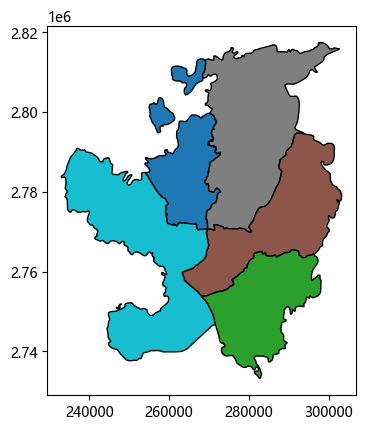

In [5]:
kunming_gpd.plot(column='dt_name', edgecolor='black', linewidth=1)



In [6]:
lclu_2017 = rio.open(path_lclu_2017)
lclu_2024 = rio.open(path_lclu_2024)
lclu_2017_bounds = lclu_2017.bounds
lclu_2024_bounds = lclu_2024.bounds
lclu_2017_arr = lclu_2017.read(1)
lclu_2024_arr = lclu_2024.read(1)
lclu_2024.meta 


{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 7026,
 'height': 8423,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 48N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(10.0, 0.0, 233000.0,
        0.0, -10.0, 2817430.0)}

In [7]:
np.unique(lclu_2017_arr)
lclu_2017_arr = lclu_2017_arr.astype(float)
lclu_2024_arr = lclu_2024_arr.astype(float)
lclu_2017_arr[lclu_2017_arr==0] = np.nan
lclu_2024_arr[lclu_2024_arr==0] = np.nan


In [8]:
np.unique(lclu_2017_arr)


array([ 1.,  2.,  4.,  5.,  7.,  8., 10., 11., nan])

Text(0.5, 1.0, 'land cover in 2024')

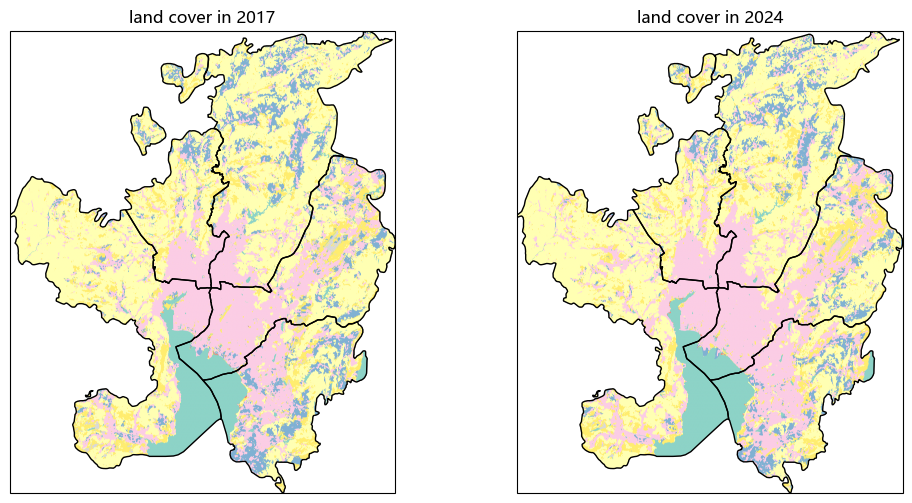

In [9]:
proj_utm48 = ccrs.UTM(zone=48, southern_hemisphere=False)
fig, ax = plt.subplots(1,2, figsize=(12,6), subplot_kw={'projection': proj_utm48})
ax[0].imshow(lclu_2017_arr, cmap='Set3',  vmin=1, vmax=11,
             extent=[lclu_2017_bounds.left, lclu_2017_bounds.right, 
                    lclu_2017_bounds.bottom, lclu_2017_bounds.top],
            transform=proj_utm48)
kunming_gpd.plot(ax=ax[0], color='none', edgecolor='black', linewidth=1)

ax[0].set_title('land cover in 2017')

ax[1].imshow(lclu_2024_arr, cmap='Set3',  vmin=1, vmax=11,
             extent=[lclu_2024_bounds.left, lclu_2024_bounds.right, 
                    lclu_2024_bounds.bottom, lclu_2024_bounds.top],
                    transform=proj_utm48)
kunming_gpd.plot(ax=ax[1], color='none', edgecolor='black', linewidth=1)
ax[1].set_title('land cover in 2024')


Text(0, 0.5, '面积（km2）')

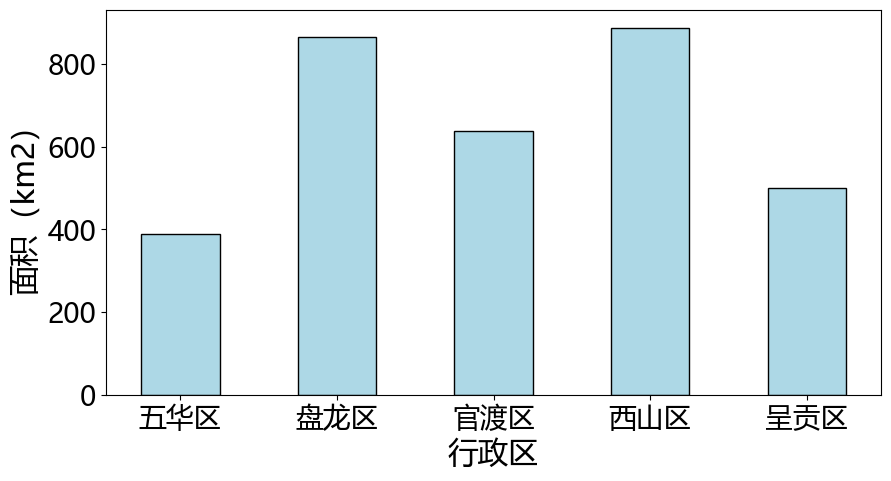

In [10]:
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(
    x=kunming_gpd['dt_name'],
    height=kunming_gpd['area(km2)'],
    facecolor='lightblue',
    edgecolor='black',
    width=0.5
)
ax.tick_params(axis='both', labelsize=20)
ax.set_xlabel('行政区', fontsize=22)
ax.set_ylabel('面积（km2）', fontsize=22)


Text(0.5, 1.0, '昆明市主城区面积占比')

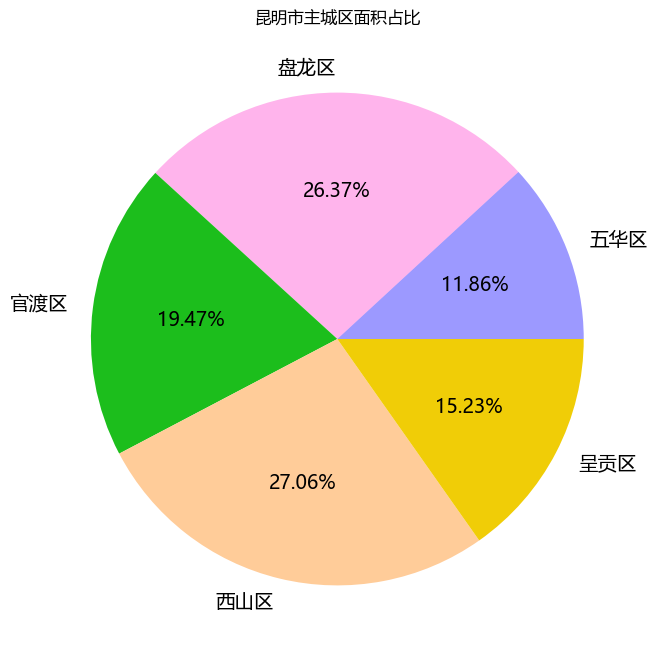

In [11]:
color = ['#9C99FF', "#FF00BF4B",'#1CBE1C', '#FFCC99','#F0CD07' ]
fig, ax = plt.subplots(figsize=(8,8))
ax.pie(x=kunming_gpd['area(km2)'],
       colors=color,
       labels=kunming_gpd['dt_name'],
       autopct='%.2f%%',
       textprops={'fontsize':14},       
       );

ax.set_title('昆明市主城区面积占比')



#### 不同地类面积对比

In [12]:
lclu_2017.meta
area_pixel = abs(lclu_2017.meta['transform'].a * lclu_2017.meta['transform'].e)/1000000
area_pixel



0.0001

In [13]:
num_pixel_wat = np.sum(lclu_2017_arr == 1) # 
num_pixel_tree = np.sum(lclu_2017_arr == 2)
num_pixel_flood_veg = np.sum(lclu_2017_arr == 4)
num_pixel_crops = np.sum(lclu_2017_arr == 5)
num_pixel_built = np.sum(lclu_2017_arr == 7)
num_pixel_bare = np.sum(lclu_2017_arr == 8)
num_pixel_snow = np.sum(lclu_2017_arr == 9)
num_pixel_cloud = np.sum(lclu_2017_arr == 10)
num_pixel_rangeland = np.sum(lclu_2017_arr == 11)
## area
area_wat = num_pixel_wat * area_pixel
area_tree = num_pixel_tree * area_pixel 
area_flood_veg = num_pixel_flood_veg * area_pixel
area_crops = num_pixel_crops * area_pixel
area_built = num_pixel_built * area_pixel
area_bare = num_pixel_bare * area_pixel
area_snow = num_pixel_snow * area_pixel
area_cloud = num_pixel_cloud * area_pixel
area_rangeland = num_pixel_rangeland * area_pixel
cla_area = {'water': area_wat,
            'tree': area_tree,
            'flood_veg': area_flood_veg,
            'crops': area_crops,
            'built': area_built,
            'bare': area_bare,
            'snow': area_snow,
            'cloud': area_cloud,
            'rangeland': area_rangeland}
cla_area


{'water': np.float64(245.4326),
 'tree': np.float64(1514.8829),
 'flood_veg': np.float64(1.5285),
 'crops': np.float64(316.3929),
 'built': np.float64(811.4203),
 'bare': np.float64(24.285800000000002),
 'snow': np.float64(0.0),
 'cloud': np.float64(0.4087),
 'rangeland': np.float64(363.4166)}

C:\Users\HP\AppData\Local\Temp\ipykernel_17288\1425195515.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['水体', '森林', '湿地','农田','建筑用地','裸地','雪盖', '云','牧场']);


Text(0, 0.5, '面积（km2）')

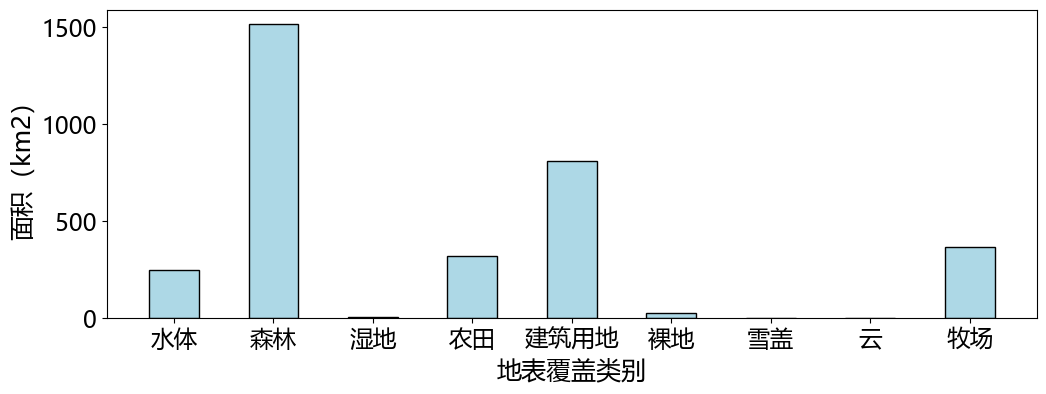

In [14]:
fig, ax = plt.subplots(figsize=(12,4))
ax.bar(
    x=cla_area.keys(),
    height=cla_area.values(),
    width=0.5,
    facecolor='lightblue',
    edgecolor='black',    
)
ax.tick_params(axis='both', labelsize=17)
ax.set_xticklabels(['水体', '森林', '湿地','农田','建筑用地','裸地','雪盖', '云','牧场']);
ax.set_xlabel('地表覆盖类别', fontsize=18)
ax.set_ylabel('面积（km2）', fontsize=18)


#### 不同区建筑物对比（选用2024期地表覆盖栅格数据）

In [15]:
kunming_gpd


,dt_adcode,dt_name,ct_adcode,ct_name,pr_adcode,pr_name,cn_adcode,cn_name,area(km2),geometry
0,530102,五华区,530100,昆明市,530000,云南省,100000,中华人民共和国,388.681330,"MULTIPOLYGON (((269466.597 2782018.804, 269686..."
1,530103,盘龙区,530100,昆明市,530000,云南省,100000,中华人民共和国,864.295297,"MULTIPOLYGON (((269635.126 2771844.039, 269631..."
2,530111,官渡区,530100,昆明市,530000,云南省,100000,中华人民共和国,638.333617,"MULTIPOLYGON (((269663.017 2770589.114, 269738..."
3,530112,西山区,530100,昆明市,530000,云南省,100000,中华人民共和国,887.075812,"MULTIPOLYGON (((248122.204 2751771.711, 248084..."
4,530114,呈贡区,530100,昆明市,530000,云南省,100000,中华人民共和国,499.363964,"MULTIPOLYGON (((282807.685 2733200.548, 282654..."


In [16]:
np.unique(lclu_2024_arr)

array([ 1.,  2.,  4.,  5.,  7.,  8.,  9., 10., 11., nan])

<GeoAxes: >

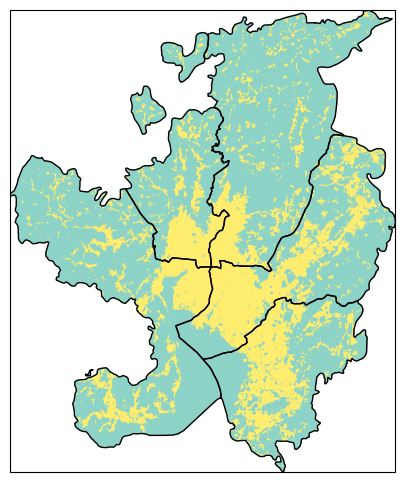

In [17]:
lclu_2024_arr_built = np.where((lclu_2024_arr != 7) & (~np.isnan(lclu_2024_arr)), 1, lclu_2024_arr)
proj_utm48 = ccrs.UTM(zone=48, southern_hemisphere=False)
fig, ax = plt.subplots(1,1, figsize=(12,6), subplot_kw={'projection': proj_utm48})
ax.imshow(lclu_2024_arr_built, cmap='Set3',  vmin=1, vmax=7,
             extent=[lclu_2024_bounds.left, lclu_2024_bounds.right, 
                    lclu_2024_bounds.bottom, lclu_2024_bounds.top],
            transform=proj_utm48)
kunming_gpd.plot(ax=ax, color='none', edgecolor='black', linewidth=1)



In [18]:
wuhua_gpd = kunming_gpd[kunming_gpd['dt_name']=='五华区']
wuhua_gpd.geometry


0    MULTIPOLYGON (((269466.597 2782018.804, 269686...
Name: geometry, dtype: geometry

In [19]:
lclu_2017_clip_data, lclu_2017_clip_transform = mask(
    dataset=lclu_2024,
    shapes = list(wuhua_gpd.geometry),
    crop=True   
)


In [20]:
num_pixel_built = np.sum(lclu_2017_clip_data == 7)
area_build_wuhua = num_pixel_built*area_pixel
area_build_wuhua


np.float64(117.70100000000001)

In [21]:
def get_area_by_district(lclu_src, geo, area_pixel, dn_class):    
    lclu_clip_data, lclu_clip_transform = mask(
        dataset=lclu_src,
        shapes = list(geo),
        crop=True   
        )
    num_pixel_cla = np.sum(lclu_clip_data == dn_class)
    area_cla = num_pixel_cla * area_pixel
    return area_cla

In [22]:
panlong_gpd = kunming_gpd[kunming_gpd['dt_name']=='盘龙区']
guandu_gpd = kunming_gpd[kunming_gpd['dt_name']=='官渡区']
xishan_gpd = kunming_gpd[kunming_gpd['dt_name']=='西山区']
chenggong_gpd = kunming_gpd[kunming_gpd['dt_name']=='呈贡区']

area_built_panlong = get_area_by_district(lclu_src=lclu_2024, 
                                          geo=panlong_gpd.geometry, 
                                          area_pixel=area_pixel, 
                                          dn_class=7)
area_built_guandu = get_area_by_district(lclu_src=lclu_2024, 
                                          geo=guandu_gpd.geometry, 
                                          area_pixel=area_pixel, 
                                          dn_class=7)
area_built_xishan = get_area_by_district(lclu_src=lclu_2024, 
                                          geo=xishan_gpd.geometry, 
                                          area_pixel=area_pixel, 
                                          dn_class=7)
area_built_chenggong = get_area_by_district(lclu_src=lclu_2024, 
                                          geo=chenggong_gpd.geometry, 
                                          area_pixel=area_pixel, 
                                          dn_class=7)


In [23]:
area_built_district = {
    '五华区': area_build_wuhua,
    '盘龙区': area_built_panlong,
    '西山区':area_built_xishan,
    '官渡区':area_built_guandu,
    '呈贡区':area_built_chenggong
}
area_built_district


{'五华区': np.float64(117.70100000000001),
 '盘龙区': np.float64(156.9505),
 '西山区': np.float64(194.00050000000002),
 '官渡区': np.float64(275.64750000000004),
 '呈贡区': np.float64(196.3939)}

Text(0, 0.5, '建筑物面积（km2）')

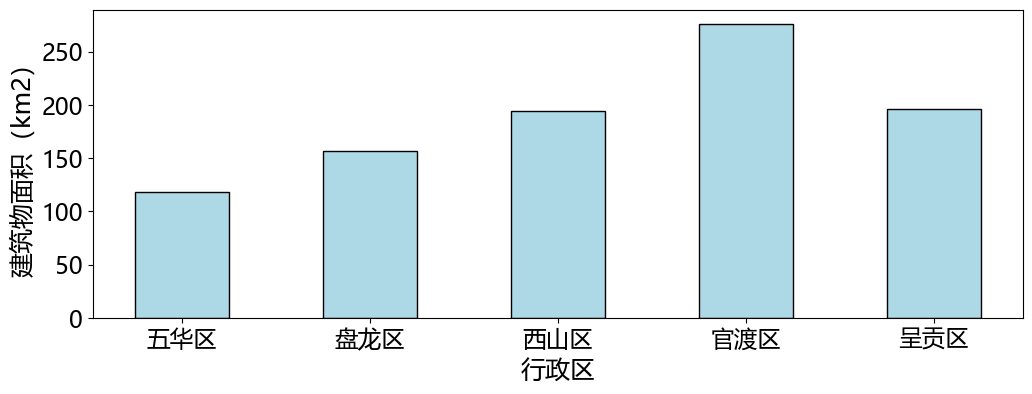

In [24]:
fig, ax = plt.subplots(figsize=(12,4))
ax.bar(
    x=area_built_district.keys(),
    height=area_built_district.values(),
    width=0.5,
    facecolor='lightblue',
    edgecolor='black',    
)
ax.tick_params(axis='both', labelsize=17)
ax.set_xlabel('行政区', fontsize=18)
ax.set_ylabel('建筑物面积（km2）', fontsize=18)



Text(0, 0.5, '建筑物面积占比（km2）')

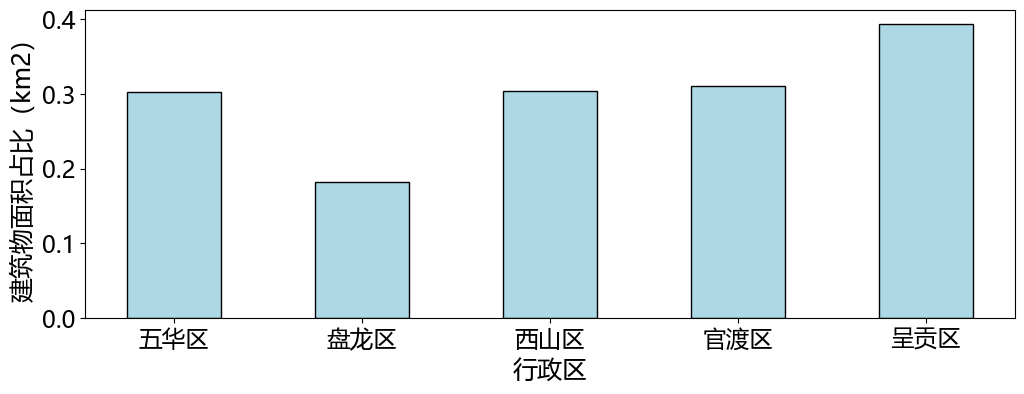

In [25]:
built_ratio = np.array(list(area_built_district.values()))/kunming_gpd['area(km2)']

fig, ax = plt.subplots(figsize=(12,4))
ax.bar(
    x=area_built_district.keys(),
    height=built_ratio,
    width=0.5,
    facecolor='lightblue',
    edgecolor='black',    
)
ax.tick_params(axis='both', labelsize=17)
ax.set_xlabel('行政区', fontsize=18)
ax.set_ylabel('建筑物面积占比（km2）', fontsize=18)


In [26]:
num_pixel_built_2017 = np.sum(lclu_2017_arr == 7)
num_pixel_built_2024 = np.sum(lclu_2024_arr == 7)
area_built_2017 = num_pixel_built_2017 * area_pixel
area_built_2024 = num_pixel_built_2024 * area_pixel

area_built_timeseries = {
    '2017': area_built_2017,
    '2024': area_built_2024
}

Text(0, 0.5, '建筑物面积（km2）')

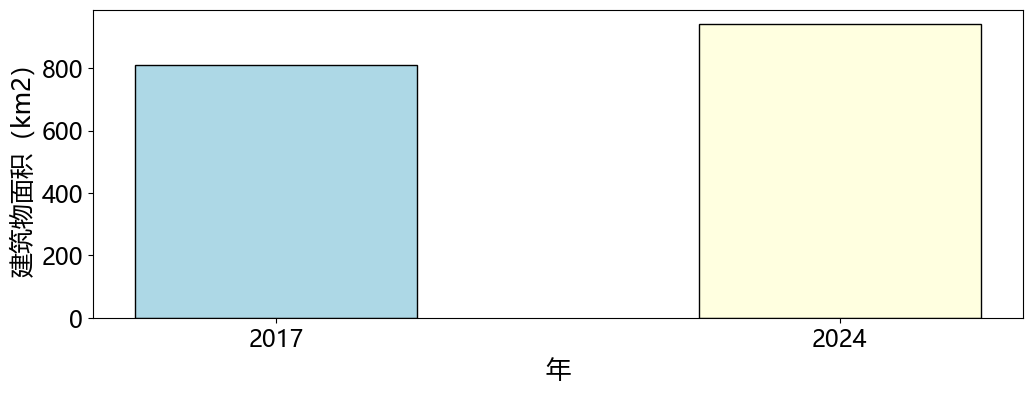

In [27]:
fig, ax = plt.subplots(figsize=(12,4))
ax.bar(
    x=area_built_timeseries.keys(),
    height=area_built_timeseries.values(),
    width=0.5,
    facecolor=['lightblue', 'lightyellow'],
    edgecolor='black')

ax.tick_params(axis='both', labelsize=17)
ax.set_xlabel('年', fontsize=18)
ax.set_ylabel('建筑物面积（km2）', fontsize=18)


In [28]:
lclu_2017_arr_built = np.where((lclu_2017_arr != 7) & (~np.isnan(lclu_2017_arr)), 0, lclu_2017_arr)
lclu_2024_arr_built = np.where((lclu_2024_arr != 7) & (~np.isnan(lclu_2024_arr)), 0, lclu_2024_arr)
lclu_2017_arr_built[lclu_2017_arr_built==7] = 1
lclu_2024_arr_built[lclu_2024_arr_built==7] = 1
print(np.unique(lclu_2017_arr_built))
print(np.unique(lclu_2024_arr_built))


[ 0.  1. nan]
[ 0.  1. nan]


In [29]:
## -1:减少，0：不变，1：增加
dif_built_arr = lclu_2024_arr_built - lclu_2017_arr_built
np.unique(dif_built_arr)


array([-1.,  0.,  1., nan])

In [ ]:
path_built_change = 'data/data-section-6/built_change.tif'
# with rio.open(fp=path_built_change, 
#                 mode='w',
#                 driver=lclu_2017.meta['driver'],
#                 height=lclu_2017.meta['height'],
#                 width=lclu_2017.meta['width'],
#                 count=1,
#                 dtype=np.float32(),   ## 采用浮点型
#                 crs=lclu_2017.meta['crs'],
#                 transform=lclu_2017.meta['transform'],
#                 nodata=lclu_2017.meta['nodata'],
#               ) as built_change_src:
#     built_change_src.write(dif_built_arr, 1)




In [30]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# 分类数据（DN值对应类别）
classes = np.array([-1, 0, 1, 2])   # DN值区间：[-1, 0), [0, 1), [1, 2)]

# 定义颜色和边界
colors = ["#00FFFF", "#C0C0C0", "#FF00FF"]   # 
cmap = ListedColormap(colors)
norm = BoundaryNorm(classes, cmap.N)



<GeoAxes: >

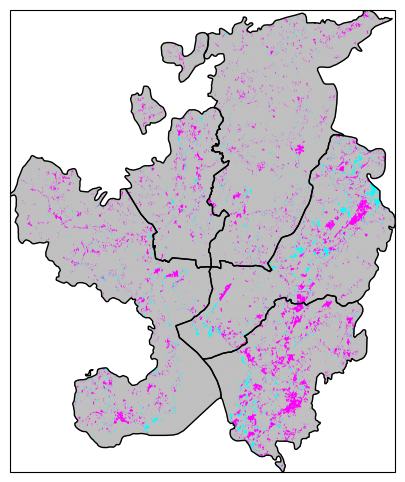

In [31]:
proj_utm48 = ccrs.UTM(zone=48, southern_hemisphere=False)
fig, ax = plt.subplots(1,1, figsize=(12,6), subplot_kw={'projection': proj_utm48})
ax.imshow(dif_built_arr, cmap=cmap, norm=norm,
             extent=[lclu_2024_bounds.left, lclu_2024_bounds.right, 
                    lclu_2024_bounds.bottom, lclu_2024_bounds.top],
            transform=proj_utm48)
kunming_gpd.plot(ax=ax, color='none', edgecolor='black', linewidth=1)


In [37]:
built_change_src = rio.open(fp=path_built_change,  mode='r')
built_increase_wuhua = get_area_by_district(built_change_src, wuhua_gpd['geometry'], area_pixel, 1)
built_decrease_wuhua = get_area_by_district(built_change_src, wuhua_gpd['geometry'], area_pixel, -1)
built_increase_panlong = get_area_by_district(built_change_src, panlong_gpd['geometry'], area_pixel, 1)
built_decrease_panlong = get_area_by_district(built_change_src, panlong_gpd['geometry'], area_pixel, -1)
built_increase_guandu = get_area_by_district(built_change_src, guandu_gpd['geometry'], area_pixel, 1)
built_decrease_guandu = get_area_by_district(built_change_src, guandu_gpd['geometry'], area_pixel, -1)
built_increase_xishan = get_area_by_district(built_change_src, xishan_gpd['geometry'], area_pixel, 1)
built_decrease_xishan = get_area_by_district(built_change_src, xishan_gpd['geometry'], area_pixel, -1)
built_increase_chenggong = get_area_by_district(built_change_src, chenggong_gpd['geometry'], area_pixel, 1)
built_decrease_chenggong = get_area_by_district(built_change_src, chenggong_gpd['geometry'], area_pixel, -1)


In [39]:
built_increase_district = {
    '五华区': built_increase_wuhua,
    '盘龙区': built_increase_panlong,
    '官渡区': built_increase_guandu,
    '西山区': built_increase_xishan,
    '呈贡区': built_increase_chenggong 
}
built_decrease_district = {
    '五华区': built_decrease_wuhua,
    '盘龙区': built_decrease_panlong,
    '官渡区': built_decrease_guandu,
    '西山区': built_decrease_xishan,
    '呈贡区': built_decrease_chenggong 
}
built_decrease_district




{'五华区': np.float64(4.1516),
 '盘龙区': np.float64(6.3303),
 '官渡区': np.float64(22.377100000000002),
 '西山区': np.float64(10.3032),
 '呈贡区': np.float64(11.2857)}

In [44]:
built_increase_district.keys()

dict_keys(['五华区', '盘龙区', '官渡区', '西山区', '呈贡区'])

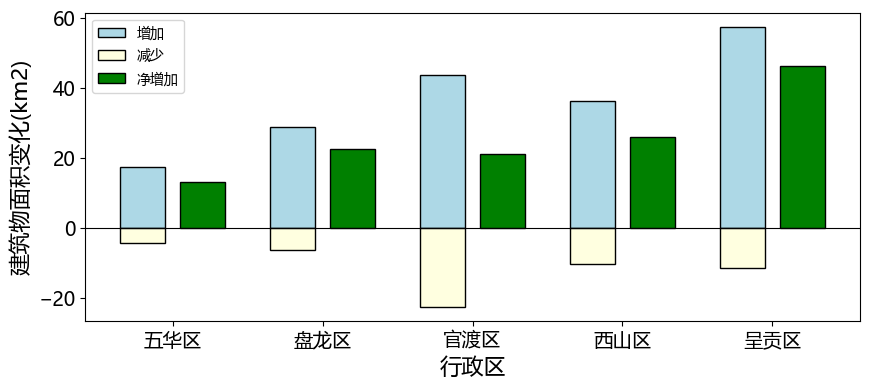

In [61]:
fig, ax = plt.subplots(figsize=(10, 4))
x_num = np.arange(len(built_increase_district))
ax.bar(
        # x = built_increase_district.keys(), 
        x = x_num,
        height= built_increase_district.values(),
        facecolor='lightblue', 
        label='增加',
        edgecolor='black', 
        width=0.3) 
ax.bar(
        # x = built_increase_district.keys(),
        x = x_num, 
        height= np.array(list(built_decrease_district.values()))*-1,
        facecolor='lightyellow', 
        label='减少',
        edgecolor='black', 
        width=0.3) 

ax.bar(
        # x=built_decrease_district.keys(), 
        x = x_num+0.4,
        height=np.array(list(built_increase_district.values()))-np.array(list(built_decrease_district.values())),
        facecolor='green', 
        edgecolor='black', 
        label='净增加',        
        width=0.3) 

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(ticks=x_num+0.2, labels=list(built_increase_district.keys()))
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel('行政区', fontsize=16)
ax.set_ylabel('建筑物面积变化(km2)', fontsize=16)
ax.legend()


In [5]:
## 1.申，2.邱，3.邹，4，周
import numpy as np 
np.random.randint(1,5)



3